In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [2]:
MEANS = [-2.0, -1.0, 0.0, 1.0, 2.0]  
STD_DEV = 0.05

BATCH_SIZE = 512
N_STEPS = 50
N_EPOCHS = 5000
LR = 1e-3

N_SAMPLES = 5000

MODE_THRESHOLD = 1 * STD_DEV    
DEAD_ZONE_THRESHOLD = 3 * STD_DEV 

In [3]:
print("STEP 1.2 - TEST A: 5 GAUSSIANS (1D)")

print(f"Means: {MEANS}")
print(f"Std Dev: {STD_DEV}")
print(f"Mode Region: |x - μ| < {MODE_THRESHOLD}")
print(f"Dead Zone: |x - μ| > {DEAD_ZONE_THRESHOLD}")
print(f"Expected Dead Zones: -1.5, -0.5, 0.5, 1.5 (between modes)")

STEP 1.2 - TEST A: 5 GAUSSIANS (1D)
Means: [-2.0, -1.0, 0.0, 1.0, 2.0]
Std Dev: 0.05
Mode Region: |x - μ| < 0.05
Dead Zone: |x - μ| > 0.15000000000000002
Expected Dead Zones: -1.5, -0.5, 0.5, 1.5 (between modes)


In [4]:
def get_region(x, return_distance=False):
    min_dist = min(abs(x - m) for m in MEANS)
    
    if min_dist < MODE_THRESHOLD:
        region = "Mode"
    elif min_dist > DEAD_ZONE_THRESHOLD:
        region = "DeadZone"
    else:
        region = "Transition"
    
    if return_distance:
        return region, min_dist
    return region


In [5]:
def get_batch(batch_size):
    indices = torch.randint(0, 5, (batch_size,)) 
    means = torch.tensor(MEANS)[indices].float()
    data = torch.normal(means, STD_DEV)
    return data.unsqueeze(1)

In [6]:
class SimpleDiffusionNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128),
            nn.Mish(),
            nn.Linear(128, 128),
            nn.Mish(),
            nn.Linear(128, 128),
            nn.Mish(),
            nn.Linear(128, 1)
        )
    
    def forward(self, x, t):
        t_input = (t.view(-1, 1) / N_STEPS) * 2 - 1
        inp = torch.cat([x, t_input], dim=1)
        return self.net(inp)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nTraining on: {device}")

model = SimpleDiffusionNet().to(device)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=LR, total_steps=N_EPOCHS)

# Noise schedule
betas = torch.linspace(1e-4, 0.02, N_STEPS).to(device)
alphas = 1 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

print(f"Training for {N_EPOCHS} epochs...")
for epoch in tqdm(range(N_EPOCHS), desc="Training"):
    optimizer.zero_grad()
    x0 = get_batch(BATCH_SIZE).to(device)
    t = torch.randint(0, N_STEPS, (BATCH_SIZE,)).to(device)
    noise = torch.randn_like(x0)
    
    a_bar = alphas_cumprod[t].view(-1, 1)
    xt = torch.sqrt(a_bar) * x0 + torch.sqrt(1 - a_bar) * noise
    
    noise_pred = model(xt, t)
    loss = nn.MSELoss()(noise_pred, noise)
    
    loss.backward()
    optimizer.step()
    scheduler.step()

print("Training complete!\n")


Training on: cuda
Training for 5000 epochs...


Training: 100%|██████████| 5000/5000 [00:39<00:00, 125.62it/s]

Training complete!



In [8]:
print(f"Generating {N_SAMPLES} samples with trajectory tracking...")
model.eval()

xt = torch.randn(N_SAMPLES, 1).to(device)
trajectory_stack = []

with torch.no_grad():
    for i in reversed(range(N_STEPS)):
        t = torch.full((N_SAMPLES,), i, dtype=torch.long).to(device)
        noise_pred = model(xt, t)
        
        a_bar = alphas_cumprod[t].view(-1, 1)
        x0_pred = (xt - torch.sqrt(1 - a_bar) * noise_pred) / torch.sqrt(a_bar)
        
        trajectory_stack.append(x0_pred.cpu().float().numpy())
        
        if i > 0:
            noise = torch.randn_like(xt)
            beta = betas[t].view(-1, 1)
            alpha = alphas[t].view(-1, 1)
            xt = (xt - (beta / torch.sqrt(1 - a_bar)) * noise_pred) / torch.sqrt(alpha) + torch.sqrt(beta) * noise
        else:
            xt = x0_pred

trajectories = np.array(trajectory_stack).transpose(1, 0, 2).squeeze()
final_samples = trajectories[:, -1]

print("Sampling complete!\n")

Generating 5000 samples with trajectory tracking...
Sampling complete!



In [9]:
print("VARIANCE ANALYSIS (Last 15 Steps)")

start_idx = N_STEPS - 15
end_idx = N_STEPS
variances = np.var(trajectories[:, start_idx:end_idx].astype(np.float32), axis=1)

mode_vars = []
dead_vars = []
transition_vars = []

for i, x in enumerate(final_samples):
    region = get_region(x)
    if region == "Mode":
        mode_vars.append(variances[i])
    elif region == "DeadZone":
        dead_vars.append(variances[i])
    else:
        transition_vars.append(variances[i])

if len(mode_vars) > 0 and len(dead_vars) > 0:
    mean_mode_var = np.mean(mode_vars)
    mean_dead_var = np.mean(dead_vars)
    ratio = mean_dead_var / mean_mode_var if mean_mode_var > 0 else 0
else:
    ratio = 0
    mean_mode_var = np.mean(mode_vars) if mode_vars else 0
    mean_dead_var = np.mean(dead_vars) if dead_vars else 0

VARIANCE ANALYSIS (Last 15 Steps)


In [10]:
print(f"\nSample Distribution:")
print(f"  Mode samples: {len(mode_vars)} ({100*len(mode_vars)/N_SAMPLES:.1f}%)")
print(f"  Dead Zone samples: {len(dead_vars)} ({100*len(dead_vars)/N_SAMPLES:.1f}%)")
print(f"  Transition samples: {len(transition_vars)} ({100*len(transition_vars)/N_SAMPLES:.1f}%)")

print(f"\nVariance Statistics:")
print(f"  Mean variance (Mode): {mean_mode_var:.6f}")
print(f"  Mean variance (Dead): {mean_dead_var:.6f}")

print(f"RATIO: {ratio:.2f}")
print(f"THRESHOLD: 5.0")
print(f"STATUS: {'PASS' if ratio > 5.0 else 'FAIL'}")


Sample Distribution:
  Mode samples: 3098 (62.0%)
  Dead Zone samples: 129 (2.6%)
  Transition samples: 1773 (35.5%)

Variance Statistics:
  Mean variance (Mode): 0.002065
  Mean variance (Dead): 0.018172
RATIO: 8.80
THRESHOLD: 5.0
STATUS: PASS



Visualization saved to: step1_2_test_a_5gaussians.png


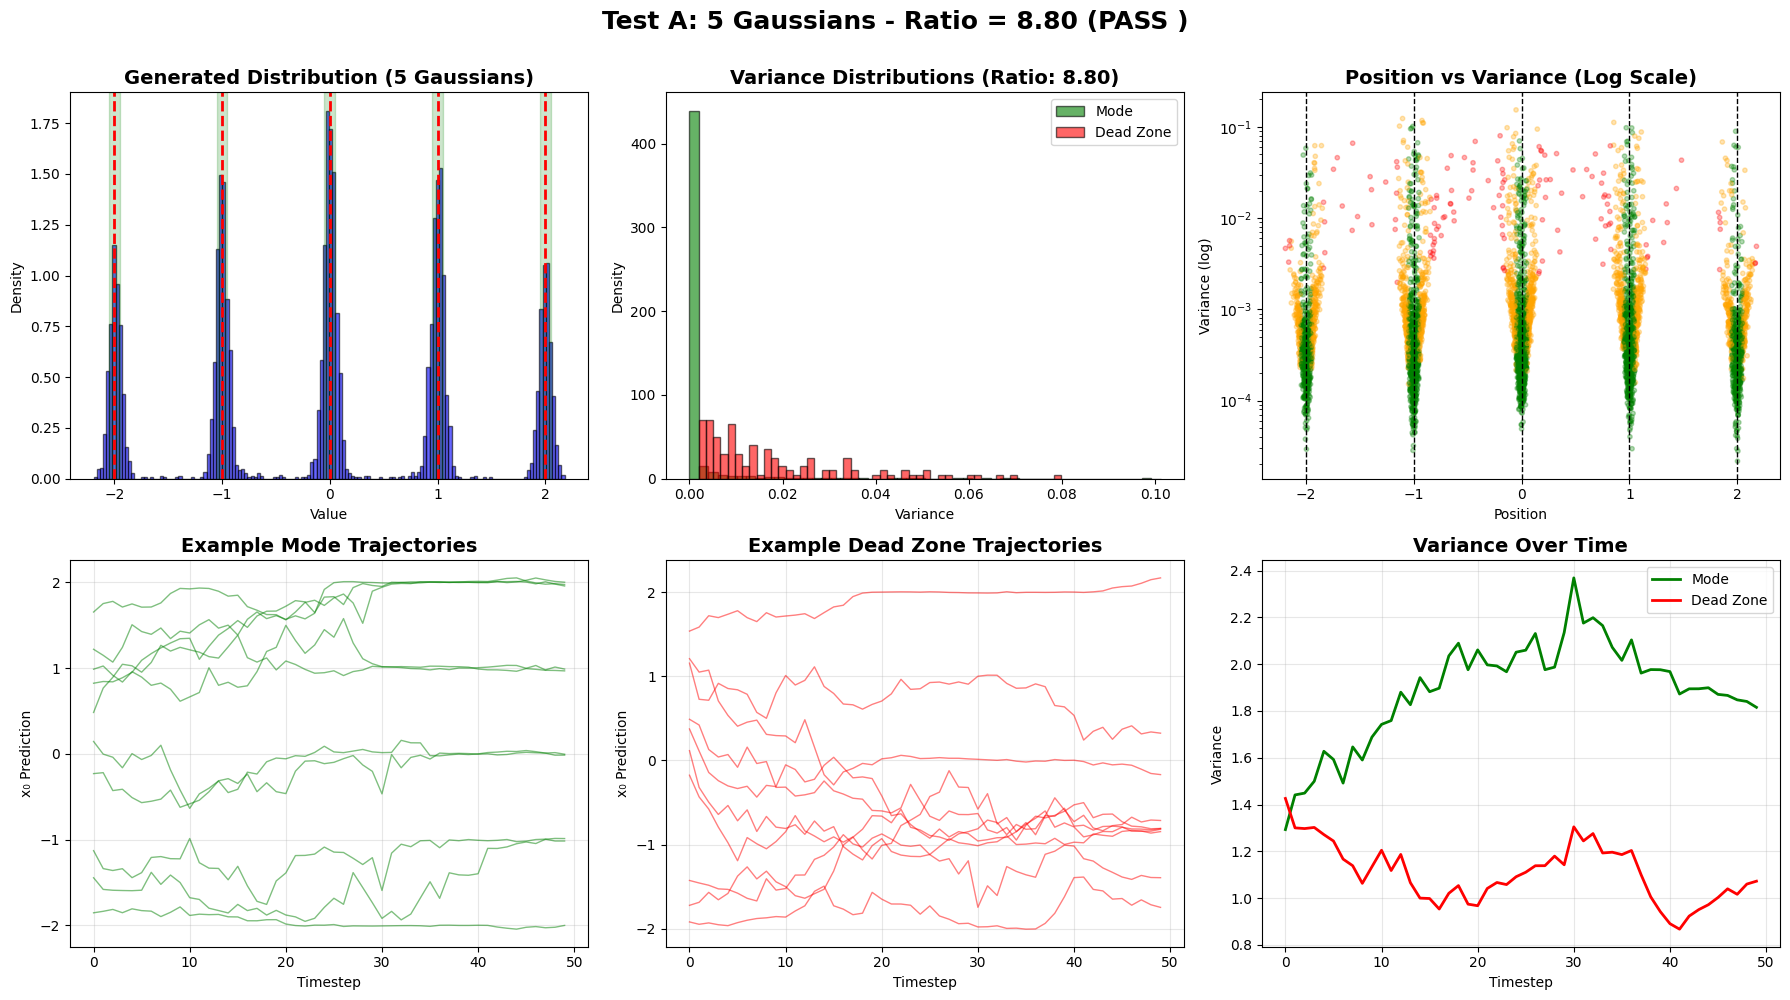

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

ax = axes[0, 0]
ax.hist(final_samples, bins=150, density=True, alpha=0.6, color='blue', edgecolor='black')
for m in MEANS:
    ax.axvline(m, color='red', linestyle='--', linewidth=2)
    ax.axvspan(m - MODE_THRESHOLD, m + MODE_THRESHOLD, alpha=0.2, color='green')
ax.set_title("Generated Distribution (5 Gaussians)", fontsize=14, fontweight='bold')
ax.set_xlabel("Value")
ax.set_ylabel("Density")

ax = axes[0, 1]
if mode_vars and dead_vars:
    ax.hist(mode_vars, bins=50, alpha=0.6, label='Mode', density=True, color='green', edgecolor='black')
    ax.hist(dead_vars, bins=50, alpha=0.6, label='Dead Zone', density=True, color='red', edgecolor='black')
    ax.legend()
ax.set_title(f"Variance Distributions (Ratio: {ratio:.2f})", fontsize=14, fontweight='bold')
ax.set_xlabel("Variance")
ax.set_ylabel("Density")

ax = axes[0, 2]
colors = ['green' if get_region(x) == "Mode" else 'red' if get_region(x) == "DeadZone" else 'orange' 
          for x in final_samples]
ax.scatter(final_samples, variances, alpha=0.3, s=10, c=colors)
for m in MEANS:
    ax.axvline(m, color='black', linestyle='--', linewidth=1)
ax.set_yscale('log')
ax.set_title("Position vs Variance (Log Scale)", fontsize=14, fontweight='bold')
ax.set_xlabel("Position")
ax.set_ylabel("Variance (log)")

ax = axes[1, 0]
mode_indices = [i for i, x in enumerate(final_samples) if get_region(x) == "Mode"][:10]
for idx in mode_indices:
    ax.plot(trajectories[idx], alpha=0.5, color='green', linewidth=1)
ax.set_title("Example Mode Trajectories", fontsize=14, fontweight='bold')
ax.set_xlabel("Timestep")
ax.set_ylabel("x₀ Prediction")
ax.grid(alpha=0.3)

ax = axes[1, 1]
dead_indices = [i for i, x in enumerate(final_samples) if get_region(x) == "DeadZone"][:10]
if dead_indices:
    for idx in dead_indices:
        ax.plot(trajectories[idx], alpha=0.5, color='red', linewidth=1)
else:
    ax.text(0.5, 0.5, "No Dead Zone Samples", ha='center', va='center', transform=ax.transAxes)
ax.set_title("Example Dead Zone Trajectories", fontsize=14, fontweight='bold')
ax.set_xlabel("Timestep")
ax.set_ylabel("x₀ Prediction")
ax.grid(alpha=0.3)

ax = axes[1, 2]
if mode_indices:
    mode_var_over_time = np.var([trajectories[i] for i in mode_indices[:50]], axis=0)
    ax.plot(mode_var_over_time, label='Mode', color='green', linewidth=2)
if dead_indices:
    dead_var_over_time = np.var([trajectories[i] for i in dead_indices[:50]], axis=0)
    ax.plot(dead_var_over_time, label='Dead Zone', color='red', linewidth=2)
ax.set_title("Variance Over Time", fontsize=14, fontweight='bold')
ax.set_xlabel("Timestep")
ax.set_ylabel("Variance")
ax.legend()
ax.grid(alpha=0.3)

fig.suptitle(f'Test A: 5 Gaussians - Ratio = {ratio:.2f} ({"PASS " if ratio > 5.0 else "FAIL "})', 
             fontsize=18, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.99])

plt.savefig('phase1_Part2_results_clean.png',
            dpi=200,
            bbox_inches='tight')
print("\nVisualization saved to: step1_2_test_a_5gaussians.png")
plt.show()
